In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print(X.shape)
print(y.shape)

(1797, 64)
(1797,)


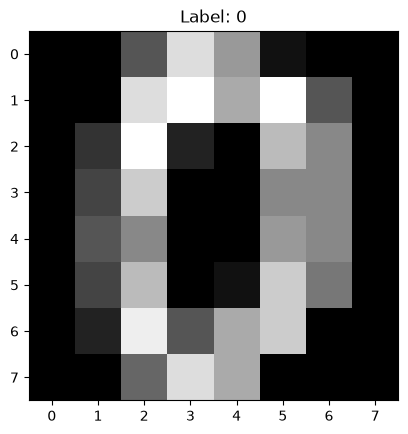

In [3]:
plt.imshow(digits.images[0], cmap="gray")
plt.title(f"Label: {digits.target[0]}")
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [7]:
train_dataset = TensorDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

In [8]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.net(x)

In [9]:
model = DigitClassifier()
print(model)

DigitClassifier(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
for epoch in range(20):
    total_loss = 0

    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)

        loss = criterion(outputs, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"第 {epoch+1} 轮，loss = {total_loss:.4f}")

第 1 轮，loss = 81.6752
第 2 轮，loss = 27.5465
第 3 轮，loss = 10.3931
第 4 轮，loss = 5.9460
第 5 轮，loss = 3.9229
第 6 轮，loss = 2.8273
第 7 轮，loss = 2.0044
第 8 轮，loss = 1.6037
第 9 轮，loss = 1.1884
第 10 轮，loss = 0.9615
第 11 轮，loss = 0.7575
第 12 轮，loss = 0.5864
第 13 轮，loss = 0.4820
第 14 轮，loss = 0.3889
第 15 轮，loss = 0.3223
第 16 轮，loss = 0.2661
第 17 轮，loss = 0.2323
第 18 轮，loss = 0.1998
第 19 轮，loss = 0.1771
第 20 轮，loss = 0.1542


In [12]:
with torch.no_grad():
    outputs = model(X_test)
    predictions = torch.argmax(outputs, dim=1)

accuracy = (predictions == y_test).float().mean()

print("测试集准确率：", accuracy.item())

测试集准确率： 0.980555534362793


In [13]:
print("预测结果：", predictions[:10])
print("真实结果：", y_test[:10])

预测结果： tensor([6, 9, 3, 7, 2, 1, 5, 2, 5, 2])
真实结果： tensor([6, 9, 3, 7, 2, 1, 5, 2, 5, 2])


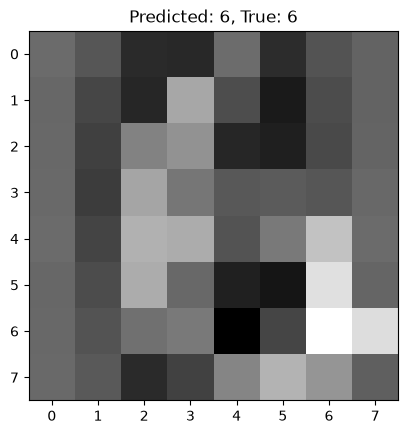

In [14]:
index = 0

image = X_test[index].reshape(8, 8)

plt.imshow(image, cmap="gray")
plt.title(f"Predicted: {predictions[index].item()}, True: {y_test[index].item()}")
plt.show()